In [1]:
### Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# dataset_Porter

In [5]:
### Load Data
data = pd.read_csv('dataset_Porter.csv')

In [7]:
### Display first few rows
display(data.head())

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


In [9]:
### Data structure and basic info
display(data.info())
display(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

None

,market_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
count,196441.000000,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000
mean,2.978706,2.882352,3.196391,2682.331402,2.670791,686.218470,1159.588630,44.808093,41.739747,58.050065
std,1.524867,1.503771,2.666546,1823.093688,1.630255,522.038648,558.411377,34.526783,32.145733,52.661830
min,1.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000
25%,2.000000,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000
50%,3.000000,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000
75%,4.000000,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000
max,6.000000,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000


In [11]:
### Feature Engineering
# Convert timestamps to datetime format
data['created_at'] = pd.to_datetime(data['created_at'])
data['actual_delivery_time'] = pd.to_datetime(data['actual_delivery_time'])

In [13]:
### Create target column: delivery_time_in_minutes
data['delivery_time_in_minutes'] = (data['actual_delivery_time'] - data['created_at']).dt.total_seconds() / 60

In [15]:
### Extract hour of the day and day of the week
data['order_hour'] = data['created_at'].dt.hour
data['order_day'] = data['created_at'].dt.dayofweek


In [17]:
### Handling null values
data.dropna(inplace=True)

In [33]:
### Encoding categorical columns
le = LabelEncoder()
data['store_primary_category'] = le.fit_transform(data['store_primary_category'])

In [35]:
### Ensure all columns are numeric
non_numeric_cols = data.select_dtypes(exclude=['number']).columns.tolist()
print("Non-numeric columns before encoding:", non_numeric_cols)
for col in non_numeric_cols:
    data[col] = le.fit_transform(data[col].astype(str))

Non-numeric columns before encoding: ['created_at', 'actual_delivery_time', 'store_id']


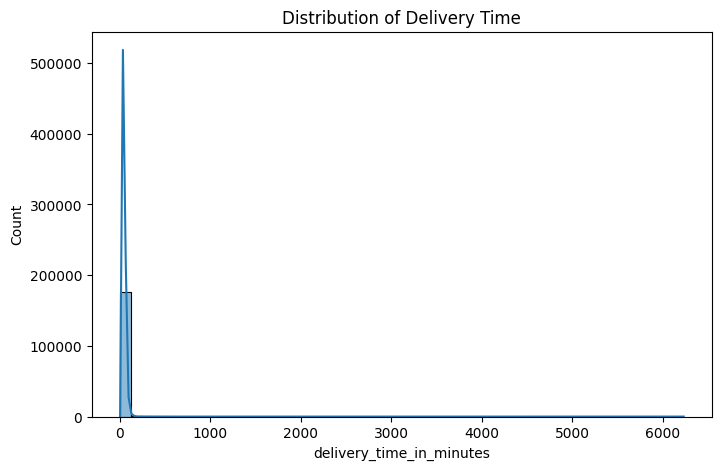

In [37]:
### Data visualization
plt.figure(figsize=(8, 5))
sns.histplot(data['delivery_time_in_minutes'], bins=50, kde=True)
plt.title('Distribution of Delivery Time')
plt.show()

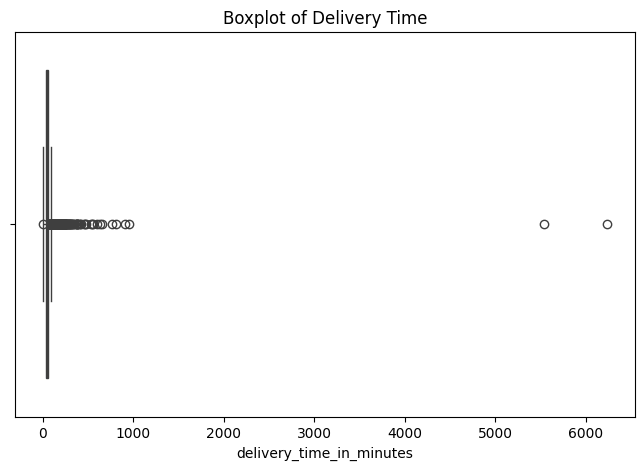

In [39]:
### Checking for outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['delivery_time_in_minutes'])
plt.title('Boxplot of Delivery Time')
plt.show()

In [41]:
### Outlier removal using IQR
Q1 = data['delivery_time_in_minutes'].quantile(0.25)
Q3 = data['delivery_time_in_minutes'].quantile(0.75)
IQR = Q3 - Q1

In [43]:
filtered_data = data[(data['delivery_time_in_minutes'] >= (Q1 - 1.5 * IQR)) & (data['delivery_time_in_minutes'] <= (Q3 + 1.5 * IQR))]

In [45]:
### Splitting data
X = filtered_data.drop(columns=['created_at', 'actual_delivery_time', 'delivery_time_in_minutes'])
y = filtered_data['delivery_time_in_minutes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
### Ensure all columns are numeric before scaling
print("Columns before scaling:", X_train.dtypes)

Columns before scaling: market_id                   float64
store_id                      int32
store_primary_category        int64
order_protocol              float64
total_items                   int64
subtotal                      int64
num_distinct_items            int64
min_item_price                int64
max_item_price                int64
total_onshift_partners      float64
total_busy_partners         float64
total_outstanding_orders    float64
order_hour                    int32
order_day                     int32
dtype: object


In [49]:
### Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(float))
X_test = scaler.transform(X_test.astype(float))


In [53]:
### Neural Network Model
def build_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=0.001)
    model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])
    return model


In [55]:
### Create model and train
model = build_model()
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), batch_size=32)

C:\Users\VEERANNA\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
4268/4268 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 463.4986 - mae: 16.1618 - val_loss: 175.4094 - val_mae: 10.3997
Epoch 2/100
4268/4268 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 215.8866 - mae: 11.5772 - val_loss: 173.0101 - val_mae: 10.4084
Epoch 3/100
4268/4268 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 211.5091 - mae: 11.4617 - val_loss: 173.2187 - val_mae: 10.3472
Epoch 4/100
4268/4268 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 204.3374 - mae: 11.2830 - val_loss: 172.1309 - val_mae: 10.4332
Epoch 5/100
4268/4268 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 202.4360 - mae: 11.2265 - val_loss: 171.5803 - val_mae: 10.3487
Epoch 6/100
4268/4268 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 198.4129 - mae: 11.1129 - val_loss: 171.7508 - val_mae: 10.4026
Epoch 7/100
4268/4268 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 196.6834 - mae: 11.0430 - val_loss: 175.4680 - val_mae: 10.3183
Epoch 8/100
4268/4268 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 193.2964 - mae: 10.9976 - val_loss: 170.

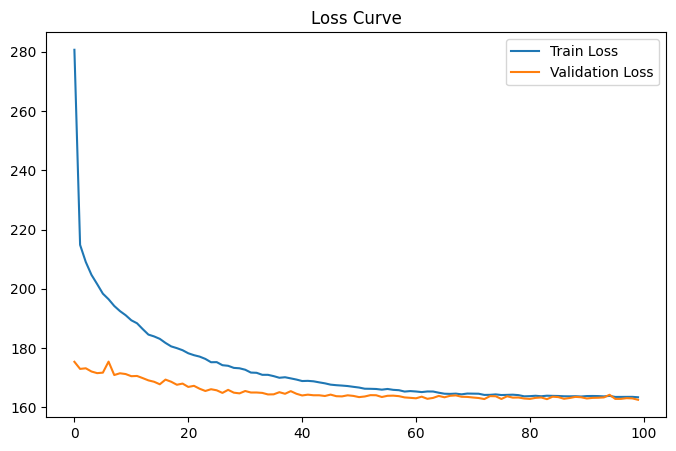

In [57]:
### Plot training history
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()


In [59]:
### Predictions and evaluation
y_pred = model.predict(X_test)
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')

1067/1067 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
MSE: 162.59
RMSE: 12.75
MAE: 10.13
R2 Score: 0.25
